Copyright (c) MONAI Consortium  
Licensed under the Apache License, Version 2.0 (the "License");  
you may not use this file except in compliance with the License.  
You may obtain a copy of the License at  
&nbsp;&nbsp;&nbsp;&nbsp;http://www.apache.org/licenses/LICENSE-2.0  
Unless required by applicable law or agreed to in writing, software  
distributed under the License is distributed on an "AS IS" BASIS,  
WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.  
See the License for the specific language governing permissions and  
limitations under the License.

# 3D Multi-organ Segmentation with UNETR  (BTCV Challenge)
# PyTorch Lightning Tutorial


This tutorial demonstrates how MONAI can be used in conjunction with PyTorch Lightning framework to construct a training workflow of UNETR on multi-organ segmentation task using the BTCV challenge dataset.

![image](../figures/btcv_transformer.png)

And it contains the following features:
1. Transforms for dictionary format data.
2. Define a new transform according to MONAI transform API.
3. Load Nifti image with metadata, load a list of images and stack them.
4. Randomly adjust intensity for data augmentation.
5. Cache IO and transforms to accelerate training and validation.
6. 3D UNETR model, Dice loss function, Mean Dice metric for multi-oorgan segmentation task.

The dataset comes from https://www.synapse.org/#!Synapse:syn3193805/wiki/217752.  

Under Institutional Review Board (IRB) supervision, 50 abdomen CT scans of were randomly selected from a combination of an ongoing colorectal cancer chemotherapy trial, and a retrospective ventral hernia study. The 50 scans were captured during portal venous contrast phase with variable volume sizes (512 x 512 x 85 - 512 x 512 x 198) and field of views (approx. 280 x 280 x 280 mm3 - 500 x 500 x 650 mm3). The in-plane resolution varies from 0.54 x 0.54 mm2 to 0.98 x 0.98 mm2, while the slice thickness ranges from 2.5 mm to 5.0 mm. 

Target: 13 abdominal organs including 1. Spleen 2. Right Kidney 3. Left Kidney 4.Gallbladder 5.Esophagus 6. Liver 7. Stomach 8.Aorta 9. IVC 10. Portal and Splenic Veins 11. Pancreas 12 Right adrenal gland 13 Left adrenal gland.

Modality: CT
Size: 30 3D volumes (24 Training + 6 Testing)  
Challenge: BTCV MICCAI Challenge

The following figure shows image patches with the organ sub-regions that are annotated in the CT (top left) and the final labels for the whole dataset (right).

Data, figures and resources are taken from: 


1. [UNETR: Transformers for 3D Medical Image Segmentation](https://arxiv.org/abs/2103.10504)

2. [High-resolution 3D abdominal segmentation with random patch network fusion (MIA)](https://www.sciencedirect.com/science/article/abs/pii/S1361841520302589)

3. [Efficient multi-atlas abdominal segmentation on clinically acquired CT with SIMPLE context learning (MIA)](https://www.sciencedirect.com/science/article/abs/pii/S1361841515000766?via%3Dihub)


![image](../figures/BTCV_organs.png)



The image patches show anatomies of a subject, including: 
1. large organs: spleen, liver, stomach. 
2. Smaller organs: gallbladder, esophagus, kidneys, pancreas. 
3. Vascular tissues: aorta, IVC, P&S Veins. 
4. Glands: left and right adrenal gland

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Project-MONAI/tutorials/blob/main/3d_segmentation/unetr_btcv_segmentation_3d_lightning.ipynb)

## Setup environment

In [1]:
!python -c "import monai" || pip install -q "monai-weekly[nibabel, einops]"
!pip install -q pytorch-lightning~=2.0
!python -c "import matplotlib" || pip install -q matplotlib
%matplotlib inline

2024-12-13 11:45:25.084307: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-12-13 11:45:25.095855: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1734086725.110256  880813 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1734086725.114491  880813 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-12-13 11:45:25.128864: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

## Setup imports

In [2]:
import os
import shutil
import tempfile

import matplotlib.pyplot as plt

from monai.losses import DiceCELoss
from monai.inferers import sliding_window_inference
from monai.transforms import (
    AsDiscrete,
    EnsureChannelFirstd,
    Compose,
    CropForegroundd,
    LoadImaged,
    Orientationd,
    RandFlipd,
    RandCropByPosNegLabeld,
    RandShiftIntensityd,
    ScaleIntensityRanged,
    Spacingd,
    RandRotate90d,
    Resized
)

from monai.config import print_config
from monai.metrics import DiceMetric
from monai.networks.nets import UNETR

from monai.data import (
    DataLoader,
    CacheDataset,
    load_decathlon_datalist,
    decollate_batch,
    list_data_collate,
)

import torch
import pytorch_lightning
from pytorch_lightning.callbacks.model_checkpoint import ModelCheckpoint

os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True
print_config()

2024-12-13 11:45:36.019201: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-12-13 11:45:36.031249: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1734086736.046405  880650 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1734086736.050835  880650 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-12-13 11:45:36.066395: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

MONAI version: 1.4.0
Numpy version: 1.26.4
Pytorch version: 2.5.1+cu124
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: 46a5272196a6c2590ca2589029eed8e4d56ff008
MONAI __file__: /home/<username>/miniconda3/envs/mri/lib/python3.10/site-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: 0.4.11
ITK version: 5.4.0
Nibabel version: 5.0.0
scikit-image version: 0.24.0
scipy version: 1.14.1
Pillow version: 11.0.0
Tensorboard version: 2.18.0
gdown version: 5.2.0
TorchVision version: 0.20.1+cu124
tqdm version: 4.66.6
lmdb version: 1.5.1
psutil version: 6.1.0
pandas version: 2.2.3
einops version: 0.8.0
transformers version: 4.40.2
mlflow version: 2.17.2
pynrrd version: 1.0.0
clearml version: 1.16.5

For details about installing the optional dependencies, please visit:
    https://docs.monai.io/en/latest/installation.html#installing-the-recommended-dependencies



## Setup data directory

You can specify a directory with the `MONAI_DATA_DIRECTORY` environment variable.  
This allows you to save results and reuse downloads.  
If not specified a temporary directory will be used.

In [3]:
directory = os.environ.get("MONAI_DATA_DIRECTORY")
if directory is not None:
    os.makedirs(directory, exist_ok=True)
root_dir = tempfile.mkdtemp() if directory is None else directory
print(root_dir)

/tmp/tmpqmiyhhr5


In [4]:
from glob import glob
import os
import nibabel as nib
import json

# RUN ONLY ONCE

# n = 0
# for im, lbl in zip(sorted(glob("./dataset/imagesTr/*.nii.gz")), sorted(glob("./dataset/labelsTr/*.nii.gz"))) :
#     # print(os.path.basename(im)[4:10], os.path.basename(lbl)[4:10])
#     # print(nib.load(im).get_fdata().shape, nib.load(lbl).get_fdata().shape)
#     imname, lblname = os.path.basename(im), os.path.basename(lbl)
#     os.rename(im, f"dataset/imagesTr/{imname[4:10]}.nii.gz")
#     os.rename(lbl, f"dataset/labelsTr/{lblname[4:10]}.nii.gz")

In [5]:
# import nibabel as nib
# for im, lbl in zip(glob("./dataset/imagesTr/*.nii.gz"), glob("./dataset/labelsTr/*.nii.gz")):
#     print(im)
#     print(nib.load(im).get_fdata().shape, nib.load(lbl).get_fdata().shape)

In [6]:
data = {
    "description": "btcv yucheng",
    "labels": {
        "0": "background",
        "1": "spleen",
        "2": "rkid",
        "3": "lkid",
        "4": "gall",
        "5": "eso",
        "6": "liver",
        "7": "sto",
        "8": "aorta",
        "9": "IVC",
        "10": "veins",
        "11": "pancreas",
        "12": "rad",
        "13": "lad"
    },
    "licence": "yt",
    "modality": {
        "0": "CT"
    },
    "name": "btcv",
    "numTest": 20,
    "numTraining": 63,
    "reference": "Monai",
    "release": "1.0 06/08/2015",
    "tensorImageSize": "3D",
    "test": [],
    "training": [],
    "validation": []
}

data["training"] = [{"image": f"imagesTr/{os.path.split(i)[1]}", "label": f"labelsTr/{os.path.split(i)[1]}"} for i in sorted(glob("./dataset/imagesTr/*.nii.gz"))[:-5]]
data["validation"] = [{"image": f"imagesTr/{os.path.split(i)[1]}", "label": f"labelsTr/{os.path.split(i)[1]}"} for i in sorted(glob("./dataset/imagesTr/*.nii.gz"))[-5:]]
data["test"] = [f"imagesTs/{os.path.split(i)[1]}" for i in sorted(glob("./dataset/imagesTs/*.nii.gz"))]

with open('dataset/dataset_0.json', 'w') as json_file:
    json.dump(data, json_file, indent=4)

# data["training"]
# data["validation"]
data["test"]


['imagesTs/026901.nii.gz',
 'imagesTs/028301.nii.gz',
 'imagesTs/028601.nii.gz',
 'imagesTs/028801.nii.gz',
 'imagesTs/029001.nii.gz',
 'imagesTs/030901.nii.gz',
 'imagesTs/035501.nii.gz',
 'imagesTs/037101.nii.gz',
 'imagesTs/039401.nii.gz',
 'imagesTs/039501.nii.gz',
 'imagesTs/040001.nii.gz',
 'imagesTs/040101.nii.gz',
 'imagesTs/040201.nii.gz',
 'imagesTs/042001.nii.gz',
 'imagesTs/042401.nii.gz',
 'imagesTs/042501.nii.gz',
 'imagesTs/042601.nii.gz',
 'imagesTs/043101.nii.gz',
 'imagesTs/043201.nii.gz',
 'imagesTs/044601.nii.gz']

## Download dataset and format in the folder.
    1. Download dataset from here: https://www.synapse.org/#!Synapse:syn3193805/wiki/89480\n
    2. Put images in the ./data/imagesTr
    3. Put labels in the ./data/labelsTr
    4. make JSON file accordingly: ./data/dataset_0.json
    Example of JSON file:

## Define the LightningModule (transform, network)
The LightningModule contains a refactoring of your training code. The following module is a refactoring of the code in spleen_segmentation_3d.ipynb:

In [7]:
class Net(pytorch_lightning.LightningModule):
    def __init__(self):
        super().__init__()

        self._model = UNETR(
            in_channels=1,
            out_channels=14,
            img_size=(96, 96, 96),
            feature_size=16,
            hidden_size=768,
            mlp_dim=3072,
            num_heads=12,
            proj_type="perceptron",
            norm_name="instance",
            res_block=True,
            conv_block=True,
            dropout_rate=0.0,
        ).to(device)

        self.loss_function = DiceCELoss(to_onehot_y=True, softmax=True)
        self.post_pred = AsDiscrete(argmax=True, to_onehot=14)
        self.post_label = AsDiscrete(to_onehot=14)
        self.dice_metric = DiceMetric(include_background=False, reduction="mean", get_not_nans=False)
        self.best_val_dice = 0
        self.best_val_epoch = 0
        self.max_epochs = 1300
        self.check_val = 30
        self.warmup_epochs = 20
        self.metric_values = []
        self.epoch_loss_values = []
        self.training_step_outputs = []
        self.validation_step_outputs = []

    def forward(self, x):
        return self._model(x)

    def prepare_data(self):
        # prepare data
        data_dir = "./dataset/"
        split_json = "dataset_0.json"
        datasets = data_dir + split_json
        datalist = load_decathlon_datalist(datasets, True, "training")
        val_files = load_decathlon_datalist(datasets, True, "validation")

        train_transforms = Compose(
            [
                LoadImaged(keys=["image", "label"]),
                EnsureChannelFirstd(keys=["image", "label"]),
                ScaleIntensityRanged(
                    keys=["image"],
                    a_min=-175,
                    a_max=250,
                    b_min=0.0,
                    b_max=1.0,
                    clip=True,
                ),
                CropForegroundd(keys=["image", "label"], source_key="image"),
                Orientationd(keys=["image", "label"], axcodes="RAS"),
                Spacingd(
                    keys=["image", "label"],
                    pixdim=(1.5, 1.5, 2.0),
                    mode=("bilinear", "nearest"),
                ),
                Resized(
                        keys=["image", "label"], 
                        spatial_size=(96, 96, 96), 
                        mode=("trilinear", "nearest")
                ),

                # RandCropByPosNegLabeld(
                #     keys=["image", "label"],
                #     label_key="label",
                #     spatial_size=(96, 96, 96),
                #     pos=1,
                #     neg=1,
                #     num_samples=4,
                #     image_key="image",
                #     image_threshold=0,
                # ),
                RandFlipd(
                    keys=["image", "label"],
                    spatial_axis=[0],
                    prob=0.10,
                ),
                RandFlipd(
                    keys=["image", "label"],
                    spatial_axis=[1],
                    prob=0.10,
                ),
                RandFlipd(
                    keys=["image", "label"],
                    spatial_axis=[2],
                    prob=0.10,
                ),
                RandRotate90d(
                    keys=["image", "label"],
                    prob=0.10,
                    max_k=3,
                ),
                RandShiftIntensityd(
                    keys=["image"],
                    offsets=0.10,
                    prob=0.50,
                ),
            ]
        )
        val_transforms = Compose(
            [
                LoadImaged(keys=["image", "label"]),
                EnsureChannelFirstd(keys=["image", "label"]),
                ScaleIntensityRanged(
                    keys=["image"],
                    a_min=-175,
                    a_max=250,
                    b_min=0.0,
                    b_max=1.0,
                    clip=True,
                ),
                CropForegroundd(keys=["image", "label"], source_key="image"),
                Orientationd(keys=["image", "label"], axcodes="RAS"),
                Spacingd(
                    keys=["image", "label"],
                    pixdim=(1.5, 1.5, 2.0),
                    mode=("bilinear", "nearest"),
                ),
            ]
        )

        self.train_ds = CacheDataset(
            data=datalist,
            transform=train_transforms,
            cache_num=24,
            cache_rate=1.0,
            num_workers=8,
        )
        self.val_ds = CacheDataset(
            data=val_files,
            transform=val_transforms,
            cache_num=6,
            cache_rate=1.0,
            num_workers=8,
        )

    def train_dataloader(self):
        train_loader = DataLoader(
            self.train_ds,
            batch_size=1,
            shuffle=True,
            num_workers=8,
            pin_memory=True,
            collate_fn=list_data_collate,
        )
        return train_loader

    def val_dataloader(self):
        val_loader = DataLoader(self.val_ds, batch_size=1, shuffle=False, num_workers=4, pin_memory=True)
        return val_loader

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self._model.parameters(), lr=1e-4, weight_decay=1e-5)
        return optimizer

    def training_step(self, batch, batch_idx):
        images, labels = (batch["image"].cuda(), batch["label"].cuda())
        output = self.forward(images)
        loss = self.loss_function(output, labels)
        self.training_step_outputs.append(loss)
        tensorboard_logs = {"train_loss": loss.item()}
        return {"loss": loss, "log": tensorboard_logs}

    def on_train_epoch_end(self):
        epoch_average = torch.stack(self.training_step_outputs).mean()
        # self.training_step_outputs.clear()  # free memory
        # self.epoch_loss_values.append(avg_loss.detach().cpu().numpy())

    def validation_step(self, batch, batch_idx):
        images, labels = batch["image"], batch["label"]
        roi_size = (96, 96, 96)
        sw_batch_size = 4
        outputs = sliding_window_inference(images, roi_size, sw_batch_size, self.forward)
        loss = self.loss_function(outputs, labels)
        outputs = [self.post_pred(i) for i in decollate_batch(outputs)]
        labels = [self.post_label(i) for i in decollate_batch(labels)]
        self.dice_metric(y_pred=outputs, y=labels)
        d = {"val_loss": loss, "val_number": len(outputs)}
        self.validation_step_outputs.append(d)
        return d

    def on_validation_epoch_end(self):
        val_loss, num_items = 0, 0
        for output in self.validation_step_outputs:
            val_loss += output["val_loss"].sum().item()
            num_items += output["val_number"]
        mean_val_dice = self.dice_metric.aggregate().item()
        self.dice_metric.reset()
        mean_val_loss = torch.tensor(val_loss / num_items)
        tensorboard_logs = {
            "val_dice": mean_val_dice,
            "val_loss": mean_val_loss,
        }
        if mean_val_dice > self.best_val_dice:
            self.best_val_dice = mean_val_dice
            self.best_val_epoch = self.current_epoch
        print(
            f"current epoch: {self.current_epoch} "
            f"current mean dice: {mean_val_dice:.4f}"
            f"\nbest mean dice: {self.best_val_dice:.4f} "
            f"at epoch: {self.best_val_epoch}"
        )
        self.metric_values.append(mean_val_dice)
        self.validation_step_outputs.clear()  # free memory
        return {"log": tensorboard_logs}

## Run the training

In [8]:
root_dir = "."

In [9]:
# initialise the LightningModule
net = Net()

# set up checkpoints
checkpoint_callback = ModelCheckpoint(dirpath=root_dir, filename="best_metric_model")

# initialise Lightning's trainer.
trainer = pytorch_lightning.Trainer(
    devices=[1],
    max_epochs=20,
    check_val_every_n_epoch=5,
    callbacks=checkpoint_callback,
    default_root_dir=root_dir,
)

# train
trainer.fit(net)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA RTX A6000') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
monai.transforms.croppad.dictionary CropForegroundd.__init__:allow_smaller: Current default value of argument `allow_smaller=True` has been deprecated since version 1.2. It will be changed to `allow_smaller=False` in version 1.5.
Loading dataset: 100%|██████████| 5/5 [00:00<00:00, 11.20it/s]
/home/arnaud/miniconda3/envs/mri/lib/python3.10/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:654: Checkpoint directory /home/arnaud/projects/MONAI/tutorials/3d_segmentation exists and is not empty.
LOCAL_RANK: 0 - CUD

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

current epoch: 0 current mean dice: 0.0036
best mean dice: 0.0036 at epoch: 0


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

current epoch: 14 current mean dice: 0.0000
best mean dice: 0.0036 at epoch: 0


Validation: |          | 0/? [00:00<?, ?it/s]

current epoch: 19 current mean dice: 0.0076
best mean dice: 0.0076 at epoch: 19


`Trainer.fit` stopped: `max_epochs=20` reached.


In [10]:
# tutorials/3d_segmentation/dataset/dataset_0.json

In [11]:
next(iter(net.training_step_outputs)).cpu().item()

3.9043290615081787

In [12]:
[i.cpu().item() for i in net.training_step_outputs]

[3.9043290615081787,
 3.873561143875122,
 3.84466552734375,
 3.8064584732055664,
 3.7677950859069824,
 3.728062629699707,
 3.7184789180755615,
 3.6804609298706055,
 3.670454740524292,
 3.63262939453125,
 3.6306731700897217,
 3.6085028648376465,
 3.586009979248047,
 3.566152334213257,
 3.53596830368042,
 3.565263271331787,
 3.5021467208862305,
 3.4936940670013428,
 3.489774703979492,
 3.485999584197998,
 3.453908920288086,
 3.4358978271484375,
 3.406045436859131,
 3.4467737674713135,
 3.4412472248077393,
 3.404066324234009,
 3.376216411590576,
 3.374486207962036,
 3.3366341590881348,
 3.3200690746307373,
 3.300313949584961,
 3.3051061630249023,
 3.3047494888305664,
 3.2977068424224854,
 3.305540084838867,
 3.268573760986328,
 3.263235569000244,
 3.252983331680298,
 3.2340426445007324,
 3.2141833305358887,
 3.2214818000793457,
 3.2242584228515625,
 3.1866049766540527,
 3.2200305461883545,
 3.2247397899627686,
 3.2006940841674805,
 3.1711912155151367,
 3.17824125289917,
 3.160682201385498

### Plot the loss and metric

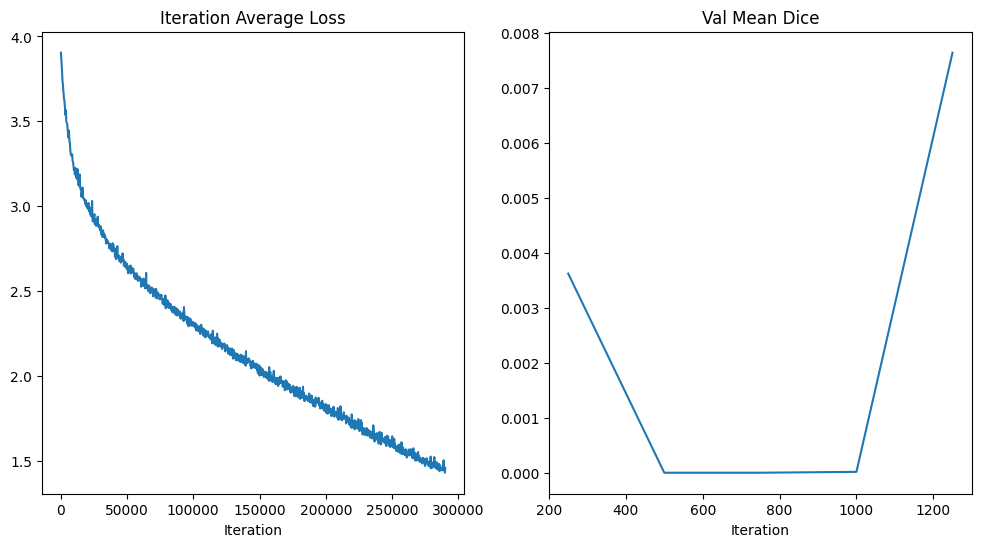

In [13]:
eval_num = 250
plt.figure("train", (12, 6))
plt.subplot(1, 2, 1)
plt.title("Iteration Average Loss")
x = [eval_num * (i + 1) for i in range(len(net.training_step_outputs))]
y = [i.cpu().item() for i in net.training_step_outputs]
plt.xlabel("Iteration")
plt.plot(x, y)
plt.subplot(1, 2, 2)
plt.title("Val Mean Dice")
x = [eval_num * (i + 1) for i in range(len(net.metric_values))]
y = net.metric_values
plt.xlabel("Iteration")
plt.plot(x, y)
plt.show()

In [17]:
net.hparams

### Check best model output with the input image and label

In [14]:
slice_map = {
    "img0035.nii.gz": 170,
    "img0036.nii.gz": 230,
    "img0037.nii.gz": 204,
    "img0038.nii.gz": 204,
    "img0039.nii.gz": 204,
    "img0040.nii.gz": 180,
}
case_num = 4
net.load_from_checkpoint(os.path.join(root_dir, "best_metric_model-v1.ckpt"))
net.eval()
net.to(device)

with torch.no_grad():
    img_name = os.path.split(net.val_ds[case_num]["image"].meta["filename_or_obj"])[1]
    img = net.val_ds[case_num]["image"]
    label = net.val_ds[case_num]["label"]
    val_inputs = torch.unsqueeze(img, 1).cuda()
    val_labels = torch.unsqueeze(label, 1).cuda()
    val_outputs = sliding_window_inference(val_inputs, (96, 96, 96), 4, net, overlap=0.8)
    plt.figure("check", (18, 6))
    plt.subplot(1, 3, 1)
    plt.title("image")
    plt.imshow(val_inputs.cpu().numpy()[0, 0, :, :, slice_map[img_name]], cmap="gray")
    plt.subplot(1, 3, 2)
    plt.title("label")
    plt.imshow(val_labels.cpu().numpy()[0, 0, :, :, slice_map[img_name]])
    plt.subplot(1, 3, 3)
    plt.title("output")
    plt.imshow(torch.argmax(val_outputs, dim=1).detach().cpu()[0, :, :, slice_map[img_name]])
    plt.show()

TypeError: The classmethod `Net.load_from_checkpoint` cannot be called on an instance. Please call it on the class type and make sure the return value is used.

### Cleanup data directory

Remove directory if a temporary was used.

In [ ]:
if directory is None:
    shutil.rmtree(root_dir)